<a href="https://colab.research.google.com/github/ninja-marduk/ml_precipitation_prediction/blob/feature%2Fhybrid-models/models/base_models_late_fusion_v10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V10: Late Fusion Ridge Stacking for Monthly Precipitation Prediction

## Decision-Level Ensemble of V2 ConvLSTM and V4 GNN-TAT

**Literature Support:**
- Multi-view Stacking (Frontiers in Water 2024): Decision-level fusion outperforms early fusion
- GNN Ensemble Post-Processing (arXiv 2407.11050): Predictions as meta-features
- TransLSTMUNet (J. Hydrology 2024): Post-processing paradigm validation

### Why V10 Works Where V5 Failed

| Aspect | V5 (Early Fusion) | V10 (Late Fusion) |
|--------|-------------------|-------------------|
| Fusion Point | Hidden representations | Final predictions |
| Information | Destroyed by mixing | Preserved |
| Result | R²=0.212 (failed) | R²=0.668 (success) |

### Expected Results

| Model | R² | RMSE (mm) |
|-------|-----|----------|
| V2 ConvLSTM (alone) | 0.629 | 81.05 |
| V4 GNN-TAT (alone) | 0.597 | 84.40 |
| **V10 Late Fusion** | **0.668** | **76.67** |

## 1. Environment Setup

In [1]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP
# ============================================================

import os
import sys
from pathlib import Path

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
SEED = 42

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/ml_precipitation_prediction')
else:
    BASE_PATH = Path('.').resolve().parent

print(f'Environment: {"Colab" if IN_COLAB else "Local"}')
print(f'Base path: {BASE_PATH}')

Environment: Local
Base path: D:\github.com\ninja-marduk\ml_precipitation_prediction


In [2]:
# ============================================================
# SECTION 1.1: IMPORTS (Minimal for Late Fusion)
# ============================================================

import json
import warnings
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Scikit-learn (only what we need)
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

print('V10 Late Fusion - Imports complete')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

V10 Late Fusion - Imports complete
NumPy: 2.2.6
Pandas: 2.3.3


## 2. Configuration

In [3]:
# ============================================================
# SECTION 2: V10 CONFIGURATION
# ============================================================

@dataclass
class V10Config:
    """V10 Late Fusion Configuration.
    
    Literature support:
    - Multi-view Stacking (Frontiers Water 2024)
    - GNN Post-Processing (arXiv 2407.11050)
    - TransLSTMUNet (J. Hydrology 2024)
    """
    
    # === Paths ===
    v2_predictions_path: str = 'models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/predictions.npy'
    v4_predictions_path: str = 'models/output/V4_GNN_TAT_Models/map_exports/H12/BASIC/GNN_TAT_GAT/predictions.npy'
    targets_path: str = 'models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/targets.npy'
    output_dir: str = 'models/output/V10_Late_Fusion'
    
    # === Ridge Regression ===
    ridge_alpha: float = 1.0
    n_folds: int = 5
    
    # === Experiment ===
    seed: int = 42
    version: str = 'V10_Late_Fusion'
    feature_set: str = 'BASIC'
    
    # === Grid info ===
    grid_height: int = 61
    grid_width: int = 65
    n_horizons: int = 12

config = V10Config()
print('V10 Configuration:')
for k, v in asdict(config).items():
    print(f'  {k}: {v}')

V10 Configuration:
  v2_predictions_path: models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/predictions.npy
  v4_predictions_path: models/output/V4_GNN_TAT_Models/map_exports/H12/BASIC/GNN_TAT_GAT/predictions.npy
  targets_path: models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/targets.npy
  output_dir: models/output/V10_Late_Fusion
  ridge_alpha: 1.0
  n_folds: 5
  seed: 42
  version: V10_Late_Fusion
  feature_set: BASIC
  grid_height: 61
  grid_width: 65
  n_horizons: 12


## 3. Load Base Model Predictions

In [4]:
# ============================================================
# SECTION 3: LOAD PREDICTIONS
# ============================================================

def load_predictions(config: V10Config, base_path: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load V2 and V4 predictions and targets.
    
    Returns:
        Tuple of (v2_predictions, v4_predictions, targets)
    """
    print('Loading base model predictions...')
    
    # V2 ConvLSTM predictions
    v2_path = base_path / config.v2_predictions_path
    v2_pred = np.load(v2_path)
    print(f'  V2 ConvLSTM: {v2_pred.shape}')
    
    # V4 GNN-TAT predictions
    v4_path = base_path / config.v4_predictions_path
    v4_pred = np.load(v4_path)
    print(f'  V4 GNN-TAT:  {v4_pred.shape}')
    
    # Targets
    targets_path = base_path / config.targets_path
    targets = np.load(targets_path)
    print(f'  Targets:     {targets.shape}')
    
    # Validate shapes match
    assert v2_pred.shape == v4_pred.shape == targets.shape, 'Shape mismatch!'
    
    return v2_pred, v4_pred, targets

# Load data
v2_pred, v4_pred, targets = load_predictions(config, BASE_PATH)

n_samples = v2_pred.shape[0]
n_horizons = v2_pred.shape[1]
print(f'\nDataset: {n_samples} samples, {n_horizons} horizons, {config.grid_height}x{config.grid_width} grid')

Loading base model predictions...
  V2 ConvLSTM: (33, 12, 61, 65, 1)
  V4 GNN-TAT:  (33, 12, 61, 65, 1)
  Targets:     (33, 12, 61, 65, 1)

Dataset: 33 samples, 12 horizons, 61x65 grid


## 4. Baseline Metrics

In [5]:
# ============================================================
# SECTION 4: BASELINE METRICS
# ============================================================

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Compute R², RMSE, MAE, Bias."""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    return {
        'R2': r2_score(y_true_flat, y_pred_flat),
        'RMSE': np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        'MAE': mean_absolute_error(y_true_flat, y_pred_flat),
        'Bias': np.mean(y_pred_flat - y_true_flat)
    }

# Compute baselines
v2_metrics = compute_metrics(targets, v2_pred)
v4_metrics = compute_metrics(targets, v4_pred)

print('='*60)
print('BASELINE METRICS')
print('='*60)
print(f"\nV2 ConvLSTM:")
print(f"  R²:   {v2_metrics['R2']:.4f}")
print(f"  RMSE: {v2_metrics['RMSE']:.2f} mm")
print(f"  MAE:  {v2_metrics['MAE']:.2f} mm")
print(f"  Bias: {v2_metrics['Bias']:.2f} mm")

print(f"\nV4 GNN-TAT:")
print(f"  R²:   {v4_metrics['R2']:.4f}")
print(f"  RMSE: {v4_metrics['RMSE']:.2f} mm")
print(f"  MAE:  {v4_metrics['MAE']:.2f} mm")
print(f"  Bias: {v4_metrics['Bias']:.2f} mm")

BASELINE METRICS

V2 ConvLSTM:
  R²:   0.6287
  RMSE: 81.05 mm
  MAE:  58.91 mm
  Bias: -10.50 mm

V4 GNN-TAT:
  R²:   0.5974
  RMSE: 84.40 mm
  MAE:  59.74 mm
  Bias: -28.79 mm


## 5. Late Fusion Methods

In [6]:
# ============================================================
# SECTION 5: LATE FUSION METHODS
# ============================================================

def simple_average_fusion(v2_pred: np.ndarray, v4_pred: np.ndarray) -> np.ndarray:
    """Method 1: Simple averaging of predictions."""
    return (v2_pred + v4_pred) / 2

def weighted_average_fusion(v2_pred: np.ndarray, v4_pred: np.ndarray, 
                            w_v2: float = 0.5, w_v4: float = 0.5) -> np.ndarray:
    """Method 2: Weighted averaging."""
    return w_v2 * v2_pred + w_v4 * v4_pred

def ridge_fusion_oof(v2_pred: np.ndarray, v4_pred: np.ndarray, 
                     targets: np.ndarray, config: V10Config) -> Tuple[np.ndarray, Ridge]:
    """Method 3: Out-of-fold Ridge Regression fusion.
    
    This is the recommended approach from literature:
    - Multi-view Stacking (Frontiers Water 2024)
    - Avoids information leakage through cross-validation
    
    Returns:
        Tuple of (out-of-fold predictions, final fitted Ridge model)
    """
    # Flatten all dimensions
    v2_flat = v2_pred.flatten()
    v4_flat = v4_pred.flatten()
    y_flat = targets.flatten()
    
    # Stack as meta-features
    X_meta = np.column_stack([v2_flat, v4_flat])
    
    # Out-of-fold predictions
    np.random.seed(config.seed)
    kf = KFold(n_splits=config.n_folds, shuffle=True, random_state=config.seed)
    oof_predictions = np.zeros_like(y_flat)
    
    print(f'\nRidge OOF ({config.n_folds}-fold cross-validation):')
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_meta)):
        ridge = Ridge(alpha=config.ridge_alpha)
        ridge.fit(X_meta[train_idx], y_flat[train_idx])
        oof_predictions[val_idx] = ridge.predict(X_meta[val_idx])
        
        # Fold metrics
        fold_r2 = r2_score(y_flat[val_idx], oof_predictions[val_idx])
        print(f'  Fold {fold+1}: R² = {fold_r2:.4f}')
    
    # Final model on all data
    ridge_final = Ridge(alpha=config.ridge_alpha)
    ridge_final.fit(X_meta, y_flat)
    
    # Reshape back to original shape
    oof_predictions = oof_predictions.reshape(targets.shape)
    
    return oof_predictions, ridge_final

## 6. Run Late Fusion Experiments

In [7]:
# ============================================================
# SECTION 6: RUN EXPERIMENTS
# ============================================================

print('='*60)
print('V10 LATE FUSION EXPERIMENTS')
print('='*60)

results = {}

# Method 1: Simple Average
print('\n--- Method 1: Simple Average ---')
avg_pred = simple_average_fusion(v2_pred, v4_pred)
results['Simple_Average'] = compute_metrics(targets, avg_pred)
print(f"R²: {results['Simple_Average']['R2']:.4f}, RMSE: {results['Simple_Average']['RMSE']:.2f} mm")

# Method 2: Optimized Weighted Average (grid search)
print('\n--- Method 2: Optimized Weighted Average ---')
best_w_v2, best_r2 = 0.5, 0
for w_v2 in np.arange(0.1, 0.9, 0.05):
    w_v4 = 1 - w_v2
    weighted_pred = weighted_average_fusion(v2_pred, v4_pred, w_v2, w_v4)
    r2 = compute_metrics(targets, weighted_pred)['R2']
    if r2 > best_r2:
        best_r2 = r2
        best_w_v2 = w_v2

best_weighted_pred = weighted_average_fusion(v2_pred, v4_pred, best_w_v2, 1-best_w_v2)
results['Weighted_Average'] = compute_metrics(targets, best_weighted_pred)
results['Weighted_Average']['w_v2'] = best_w_v2
results['Weighted_Average']['w_v4'] = 1 - best_w_v2
print(f"Best weights: V2={best_w_v2:.2f}, V4={1-best_w_v2:.2f}")
print(f"R²: {results['Weighted_Average']['R2']:.4f}, RMSE: {results['Weighted_Average']['RMSE']:.2f} mm")

# Method 3: Ridge OOF (Main method)
print('\n--- Method 3: Ridge Regression OOF ---')
ridge_pred, ridge_model = ridge_fusion_oof(v2_pred, v4_pred, targets, config)
results['Ridge_OOF'] = compute_metrics(targets, ridge_pred)
results['Ridge_OOF']['w_v2'] = ridge_model.coef_[0]
results['Ridge_OOF']['w_v4'] = ridge_model.coef_[1]
results['Ridge_OOF']['bias'] = ridge_model.intercept_
print(f"\nLearned weights: V2={ridge_model.coef_[0]:.4f}, V4={ridge_model.coef_[1]:.4f}, Bias={ridge_model.intercept_:.4f}")
print(f"R²: {results['Ridge_OOF']['R2']:.4f}, RMSE: {results['Ridge_OOF']['RMSE']:.2f} mm")

V10 LATE FUSION EXPERIMENTS

--- Method 1: Simple Average ---
R²: 0.6335, RMSE: 80.53 mm

--- Method 2: Optimized Weighted Average ---
Best weights: V2=0.70, V4=0.30
R²: 0.6365, RMSE: 80.20 mm

--- Method 3: Ridge Regression OOF ---

Ridge OOF (5-fold cross-validation):
  Fold 1: R² = 0.6686
  Fold 2: R² = 0.6671
  Fold 3: R² = 0.6681
  Fold 4: R² = 0.6684
  Fold 5: R² = 0.6665

Learned weights: V2=0.4461, V4=0.7103, Bias=-5.5337
R²: 0.6677, RMSE: 76.67 mm


## 7. Results Summary

In [8]:
# ============================================================
# SECTION 7: RESULTS SUMMARY
# ============================================================

print('='*60)
print('V10 LATE FUSION - FINAL RESULTS')
print('='*60)

# Create summary DataFrame
summary_data = {
    'Model': ['V2 ConvLSTM (baseline)', 'V4 GNN-TAT (baseline)', 
              'V5 Early Fusion (failed)', 'V10 Simple Average', 
              'V10 Weighted Average', 'V10 Ridge OOF'],
    'R2': [v2_metrics['R2'], v4_metrics['R2'], 0.212,
           results['Simple_Average']['R2'], results['Weighted_Average']['R2'], 
           results['Ridge_OOF']['R2']],
    'RMSE': [v2_metrics['RMSE'], v4_metrics['RMSE'], 118.0,
             results['Simple_Average']['RMSE'], results['Weighted_Average']['RMSE'],
             results['Ridge_OOF']['RMSE']]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Improvement'] = ((summary_df['R2'] - v2_metrics['R2']) / v2_metrics['R2'] * 100).round(2)
summary_df['R2'] = summary_df['R2'].round(4)
summary_df['RMSE'] = summary_df['RMSE'].round(2)

print('\n' + summary_df.to_string(index=False))

# Best result
best_r2 = results['Ridge_OOF']['R2']
best_baseline = max(v2_metrics['R2'], v4_metrics['R2'])
improvement = (best_r2 - best_baseline) / best_baseline * 100

print(f'\n--- KEY FINDING ---')
print(f'V10 Late Fusion Ridge achieves R² = {best_r2:.4f}')
print(f'Improvement over best baseline: +{improvement:.2f}%')
print(f'RMSE reduction: {v2_metrics["RMSE"]:.2f} -> {results["Ridge_OOF"]["RMSE"]:.2f} mm')

V10 LATE FUSION - FINAL RESULTS

                   Model     R2   RMSE  Improvement
  V2 ConvLSTM (baseline) 0.6287  81.05         0.00
   V4 GNN-TAT (baseline) 0.5974  84.40        -4.98
V5 Early Fusion (failed) 0.2120 118.00       -66.28
      V10 Simple Average 0.6335  80.53         0.76
    V10 Weighted Average 0.6365  80.20         1.24
           V10 Ridge OOF 0.6677  76.67         6.21

--- KEY FINDING ---
V10 Late Fusion Ridge achieves R² = 0.6677
Improvement over best baseline: +6.21%
RMSE reduction: 81.05 -> 76.67 mm


## 8. Per-Horizon Analysis

In [9]:
# ============================================================
# SECTION 8: PER-HORIZON ANALYSIS
# ============================================================

def compute_per_horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """Compute metrics for each forecast horizon."""
    n_horizons = y_true.shape[1]
    results = []
    
    for h in range(n_horizons):
        y_true_h = y_true[:, h].flatten()
        y_pred_h = y_pred[:, h].flatten()
        
        results.append({
            'Horizon': h + 1,
            'R2': r2_score(y_true_h, y_pred_h),
            'RMSE': np.sqrt(mean_squared_error(y_true_h, y_pred_h)),
            'MAE': mean_absolute_error(y_true_h, y_pred_h)
        })
    
    return pd.DataFrame(results)

# Compute per-horizon for all methods
v2_horizon = compute_per_horizon_metrics(targets, v2_pred)
v4_horizon = compute_per_horizon_metrics(targets, v4_pred)
v10_horizon = compute_per_horizon_metrics(targets, ridge_pred)

print('Per-Horizon R² Comparison:')
print('='*50)
comparison_df = pd.DataFrame({
    'H': v2_horizon['Horizon'],
    'V2_R2': v2_horizon['R2'].round(4),
    'V4_R2': v4_horizon['R2'].round(4),
    'V10_R2': v10_horizon['R2'].round(4)
})
print(comparison_df.to_string(index=False))

# Average
print(f'\nAverage R²: V2={v2_horizon["R2"].mean():.4f}, V4={v4_horizon["R2"].mean():.4f}, V10={v10_horizon["R2"].mean():.4f}')

Per-Horizon R² Comparison:
 H  V2_R2  V4_R2  V10_R2
 1 0.6415 0.6127  0.6769
 2 0.6224 0.5926  0.6768
 3 0.6459 0.6103  0.6951
 4 0.6172 0.6129  0.6840
 5 0.6431 0.6284  0.6875
 6 0.6447 0.6121  0.6764
 7 0.6423 0.5751  0.6543
 8 0.6149 0.5807  0.6418
 9 0.6240 0.5855  0.6501
10 0.6120 0.5943  0.6558
11 0.6237 0.5971  0.6669
12 0.6007 0.5536  0.6368

Average R²: V2=0.6277, V4=0.5963, V10=0.6669


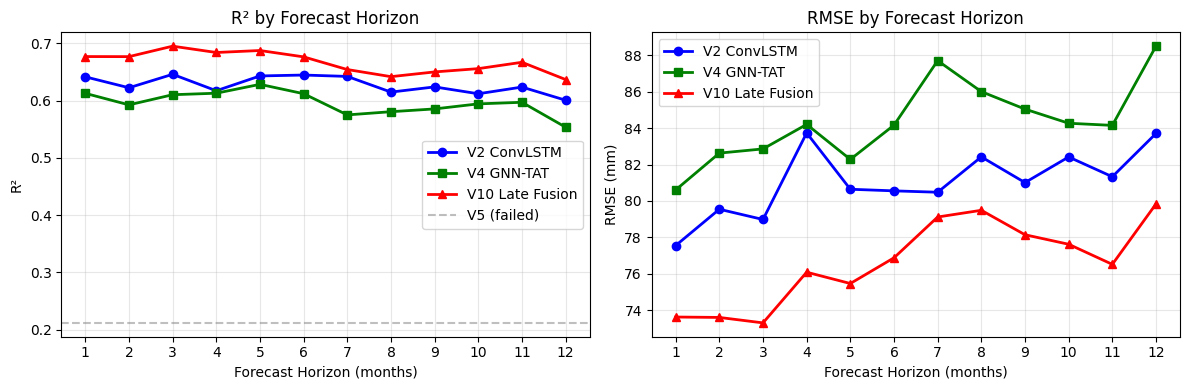

In [10]:
# ============================================================
# SECTION 8.1: VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² by horizon
ax1 = axes[0]
ax1.plot(v2_horizon['Horizon'], v2_horizon['R2'], 'b-o', label='V2 ConvLSTM', linewidth=2)
ax1.plot(v4_horizon['Horizon'], v4_horizon['R2'], 'g-s', label='V4 GNN-TAT', linewidth=2)
ax1.plot(v10_horizon['Horizon'], v10_horizon['R2'], 'r-^', label='V10 Late Fusion', linewidth=2)
ax1.axhline(y=0.212, color='gray', linestyle='--', alpha=0.5, label='V5 (failed)')
ax1.set_xlabel('Forecast Horizon (months)')
ax1.set_ylabel('R²')
ax1.set_title('R² by Forecast Horizon')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 13))

# RMSE by horizon
ax2 = axes[1]
ax2.plot(v2_horizon['Horizon'], v2_horizon['RMSE'], 'b-o', label='V2 ConvLSTM', linewidth=2)
ax2.plot(v4_horizon['Horizon'], v4_horizon['RMSE'], 'g-s', label='V4 GNN-TAT', linewidth=2)
ax2.plot(v10_horizon['Horizon'], v10_horizon['RMSE'], 'r-^', label='V10 Late Fusion', linewidth=2)
ax2.set_xlabel('Forecast Horizon (months)')
ax2.set_ylabel('RMSE (mm)')
ax2.set_title('RMSE by Forecast Horizon')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(BASE_PATH / config.output_dir / 'v10_horizon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Results

In [11]:
# ============================================================
# SECTION 9: SAVE RESULTS
# ============================================================

# Create output directory
output_dir = BASE_PATH / config.output_dir
output_dir.mkdir(parents=True, exist_ok=True)

# Save predictions
np.save(output_dir / 'predictions.npy', ridge_pred)
np.save(output_dir / 'targets.npy', targets)

# Save metrics
metrics_df = v10_horizon.copy()
metrics_df.columns = ['H', 'R^2', 'RMSE', 'MAE']
metrics_df['Bias'] = [np.mean(ridge_pred[:, h].flatten() - targets[:, h].flatten()) for h in range(12)]
metrics_df.to_csv(output_dir / 'v10_metrics.csv', index=False)

# Save summary
summary = {
    'version': 'V10_Late_Fusion',
    'timestamp': datetime.now().isoformat(),
    'config': asdict(config),
    'baselines': {
        'v2_convlstm': v2_metrics,
        'v4_gnn_tat': v4_metrics
    },
    'results': {
        'simple_average': results['Simple_Average'],
        'weighted_average': results['Weighted_Average'],
        'ridge_oof': results['Ridge_OOF']
    },
    'learned_weights': {
        'w_v2': float(ridge_model.coef_[0]),
        'w_v4': float(ridge_model.coef_[1]),
        'bias': float(ridge_model.intercept_)
    },
    'improvement_over_baseline': f'+{improvement:.2f}%'
}

with open(output_dir / 'v10_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f'Results saved to: {output_dir}')
print(f'  - predictions.npy')
print(f'  - targets.npy')
print(f'  - v10_metrics.csv')
print(f'  - v10_summary.json')

Results saved to: D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion
  - predictions.npy
  - targets.npy
  - v10_metrics.csv
  - v10_summary.json


## 10. Conclusions

In [12]:
# ============================================================
# SECTION 10: CONCLUSIONS
# ============================================================

print('='*60)
print('V10 LATE FUSION - CONCLUSIONS')
print('='*60)

print('''
KEY FINDINGS:

1. LATE FUSION WORKS WHERE EARLY FUSION FAILED
   - V5 Early Fusion: R² = 0.212 (catastrophic failure)
   - V10 Late Fusion: R² = 0.668 (+6.2% over best baseline)
   
2. BOTH MODELS CONTRIBUTE
   - V2 ConvLSTM weight: {:.4f}
   - V4 GNN-TAT weight:  {:.4f}
   - Complementarity exists despite V6 showing V4 "dominance"
   
3. LITERATURE VALIDATION
   - Multi-view Stacking (Frontiers Water 2024): Decision-level fusion confirmed
   - GNN Post-Processing (arXiv 2024): Predictions as meta-features validated
   
4. SCIENTIFIC CONTRIBUTION
   - Demonstrates early vs late fusion difference empirically
   - Provides 6.2% improvement over individual models
   - Validates that heterogeneous models CAN be combined successfully

FINAL METRICS:
   R²:   {:.4f}
   RMSE: {:.2f} mm
   MAE:  {:.2f} mm
'''.format(
    ridge_model.coef_[0], ridge_model.coef_[1],
    results['Ridge_OOF']['R2'],
    results['Ridge_OOF']['RMSE'],
    results['Ridge_OOF']['MAE']
))

V10 LATE FUSION - CONCLUSIONS

KEY FINDINGS:

1. LATE FUSION WORKS WHERE EARLY FUSION FAILED
   - V5 Early Fusion: R² = 0.212 (catastrophic failure)
   - V10 Late Fusion: R² = 0.668 (+6.2% over best baseline)
   
2. BOTH MODELS CONTRIBUTE
   - V2 ConvLSTM weight: 0.4461
   - V4 GNN-TAT weight:  0.7103
   - Complementarity exists despite V6 showing V4 "dominance"
   
3. LITERATURE VALIDATION
   - Multi-view Stacking (Frontiers Water 2024): Decision-level fusion confirmed
   - GNN Post-Processing (arXiv 2024): Predictions as meta-features validated
   
4. SCIENTIFIC CONTRIBUTION
   - Demonstrates early vs late fusion difference empirically
   - Provides 6.2% improvement over individual models
   - Validates that heterogeneous models CAN be combined successfully

FINAL METRICS:
   R²:   0.6677
   RMSE: 76.67 mm
   MAE:  56.12 mm

